In [1]:
"""
Figure 4 (panels b, c): affordance landscape heterogeneity in the human brain.

Reproduces:
  - Panel (b): distribution of affordance-landscape eigenvalues for the
    Default Mode vs. Visual network (Yeo-7), with IQR annotated.
  - Panel (c): heterogeneity (IQR of eigenvalues) of the affordance landscape
    for each Yeo-17 network, plotted against the sensorimotor-association
    (S-A) axis rank, before and after regressing out network size.
"""

import os

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.stats import linregress, pearsonr, spearmanr

# --- paths -------------------------------------------------------------
DATA_DIR = "HCP_Schaefer400_structural_conn_matrices"
ATLAS_TSV = "atlas-Schaefer2018v0143_desc-400ParcelsAllNetworks_dseg.tsv"
OUT_DIR = "results/fig4"
os.makedirs(OUT_DIR, exist_ok=True)

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}",
})

T = 1.0 

def affordance_landscape_eigs(A, T=1.0):
    """
    Cost eigenvalues (eigenvalues of W^-1) of a symmetric structural
    connectivity matrix A, per Eq. 5: w_i^-1 = 2*lam_i / (exp(2*lam_i*T) - 1).
    """
    A = np.asarray(A, dtype=float)
    lam = eigh(A, eigvals_only=True)
    with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
        w = np.where(np.abs(lam) > 1e-12, (np.exp(2 * lam * T) - 1) / (2 * lam), T)
    return 1.0 / np.abs(w)


def iqr(values):
    q75, q25 = np.percentile(values, [75, 25])
    return q75 - q25


def fmt_p(p):
    return r"$p<0.001$" if p < 0.001 else rf"$p={p:.3f}$"

Loaded 100 subjects
Default -> Default: n=91, IQR=5.193
Vis -> Vis: n=61, IQR=14.938


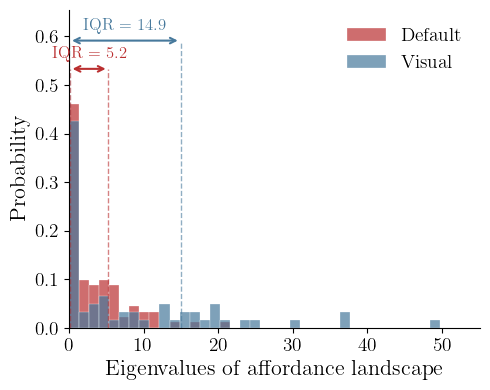

In [2]:
# load data, build Yeo-7 subnetwork matrices

matrices = {}
for file in sorted(os.listdir(DATA_DIR)):
    if file.endswith(".csv"):
        subject_id = file.replace(".csv", "")
        matrices[subject_id] = pd.read_csv(os.path.join(DATA_DIR, file), header=None).values

print(f"Loaded {len(matrices)} subjects")

atlas = pd.read_csv(ATLAS_TSV, sep="\t")
atlas["network"] = atlas["network_label"]  # Yeo-7 label
networks_7 = atlas["network"].unique()
network_indices_7 = {net: atlas.index[atlas["network"] == net].tolist() for net in networks_7}

all_subnetwork_matrices_7 = {
    subj: {net: mat[np.ix_(idx, idx)] for net, idx in network_indices_7.items()}
    for subj, mat in matrices.items()
}

# Panel (b) — Default Mode vs. Visual, affordance landscape eigenvalues
subject = list(all_subnetwork_matrices_7.keys())[0]

net_labels = ["Default", "Vis"]  # 'Vis'
colors = {"Default": "#BA2F30", "Vis": "#47799C"}
labels = {"Default": "Default", "Vis": "Visual"}

panel_b_results = {}
for target in net_labels:
    net_key = [k for k in all_subnetwork_matrices_7[subject] if target in k][0]
    cost = affordance_landscape_eigs(all_subnetwork_matrices_7[subject][net_key], T=T)
    panel_b_results[target] = {"cost": cost, "net_key": net_key, "n": len(cost)}
    print(f"{target} -> {net_key}: n={len(cost)}, IQR={iqr(cost):.3f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=14)

all_costs = np.concatenate([panel_b_results[k]["cost"] for k in panel_b_results])
bins = np.linspace(0, np.percentile(all_costs, 99.5), 40)
for target in net_labels:
    c, n = panel_b_results[target]["cost"], panel_b_results[target]["n"]
    counts, edges = np.histogram(c, bins=bins)
    ax.bar(edges[:-1], counts / n, width=np.diff(edges), align="edge",
           color=colors[target], edgecolor="white", linewidth=0.3,
           alpha=0.7, label=labels[target])

ymax_bars = ax.get_ylim()[1]
arrow_y = {"Default": ymax_bars * 1.10, "Vis": ymax_bars * 1.22}
for target in net_labels:
    q75, q25 = np.percentile(panel_b_results[target]["cost"], [75, 25])
    y = arrow_y[target]
    ax.axvline(q25, ymax=y / (ymax_bars * 1.35), color=colors[target], linestyle="--", linewidth=1, alpha=0.6)
    ax.axvline(q75, ymax=y / (ymax_bars * 1.35), color=colors[target], linestyle="--", linewidth=1, alpha=0.6)
    ax.annotate("", xy=(q75, y), xytext=(q25, y),
                arrowprops=dict(arrowstyle="<->", color=colors[target], linewidth=1.5))
    ax.text((q25 + q75) / 2, y + ymax_bars * 0.03, f"IQR = {q75 - q25:.1f}",
            color=colors[target], fontsize=12, ha="center", va="bottom")

ax.set_xlabel(r"Eigenvalues of affordance landscape", fontsize=16)
ax.set_ylabel(r"Probability", fontsize=16)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0, top=ymax_bars * 1.35)
ax.legend(frameon=False, fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig4b_{subject}_default_vs_visual.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [3]:
# load Yeo-17 subnetwork matrices + S-A axis rank

all_subnetwork_matrices_17 = {}
for subj, full_matrix in matrices.items():
    all_subnetwork_matrices_17[subj] = {}
    for net_name in atlas["network_label_17network"].unique():
        parcel_indices = atlas[atlas["network_label_17network"] == net_name]["index"].values - 1
        all_subnetwork_matrices_17[subj][net_name] = full_matrix[np.ix_(parcel_indices, parcel_indices)]

print(f"Built 17-network matrices for {len(all_subnetwork_matrices_17)} subjects.")

net_order_17 = [
    "SomMotA", "SalVentAttnA", "DefaultA", "DefaultB", "SomMotB",
    "DorsAttnA", "DorsAttnB", "ContB", "VisCent", "ContA",
    "VisPeri", "SalVentAttnB", "TempPar", "DefaultC",
    "LimbicA", "ContC", "LimbicB",
]

# S-A axis rank per network (Sydnor et al. 2021), mean over constituent parcels
sa_rank_17 = {
    "VisPeri": 40.30, "SomMotA": 44.44, "VisCent": 65.08,
    "SomMotB": 120.81, "DorsAttnA": 143.56, "DorsAttnB": 156.92,
    "ContC": 169.33, "DefaultC": 181.92, "SalVentAttnA": 209.12,
    "TempPar": 242.44, "ContA": 255.04, "LimbicA": 267.46,
    "LimbicB": 298.36, "DefaultA": 317.38, "SalVentAttnB": 325.76,
    "ContB": 348.04, "DefaultB": 348.06,
}
sa_vals_17 = np.array([sa_rank_17[net] for net in net_order_17])

# network sizes 
first_subj_17 = list(all_subnetwork_matrices_17.keys())[0]
net_sizes_17 = {net: all_subnetwork_matrices_17[first_subj_17][net].shape[0] for net in net_order_17}

# color by S-A rank (magma, reversed so sensory = light, association = dark)
cmap = mpl.colormaps["magma_r"]
norm = mpl.colors.Normalize(vmin=sa_vals_17.min(), vmax=sa_vals_17.max())
net_colors_17 = {net: cmap(norm(sa_rank_17[net])) for net in net_order_17}

# per-subject, per-network IQR of the affordance landscape eigenvalues
iqr_results_17 = {net: [] for net in net_order_17}
for subject in all_subnetwork_matrices_17:
    for net_name in net_order_17:
        cost = affordance_landscape_eigs(all_subnetwork_matrices_17[subject][net_name], T=T)
        iqr_results_17[net_name].append(iqr(cost))

print(f"Computed IQR for {len(all_subnetwork_matrices_17)} subjects x {len(net_order_17)} networks.")


def plot_iqr_vs_sa_rank(results_by_net, ylabel, out_path):
    """Shared plotting routine for panel (c), raw and size-corrected versions."""
    mean_vals = np.array([np.mean(results_by_net[net]) for net in net_order_17])
    pr, pp = pearsonr(sa_vals_17, mean_vals)
    sr, sp = spearmanr(sa_vals_17, mean_vals)

    fig, ax = plt.subplots(figsize=(7, 6))
    rng = np.random.default_rng(42)
    bw = 11 / 2

    for i, net in enumerate(net_order_17):
        color = net_colors_17[net]
        subj_vals = np.array(results_by_net[net])
        sa_x = sa_vals_17[i]

        jitter = rng.uniform(-3, 3, size=len(subj_vals))
        ax.scatter(sa_x + jitter, subj_vals, color=color, alpha=0.25, s=17, zorder=1, edgecolors="none")

        q25, q50, q75 = np.percentile(subj_vals, [25, 50, 75])
        iqr_val = q75 - q25
        lo = max(subj_vals.min(), q25 - 1.5 * iqr_val)
        hi = min(subj_vals.max(), q75 + 1.5 * iqr_val)

        ax.add_patch(plt.Rectangle((sa_x - bw, q25), bw * 2, iqr_val, facecolor="white", edgecolor="none", zorder=1.9))
        face_rgba = mpl.colors.to_rgba(color, alpha=0.50)
        ax.add_patch(plt.Rectangle((sa_x - bw, q25), bw * 2, iqr_val,
                                    linewidth=1.3, edgecolor=color, facecolor=face_rgba, zorder=2))
        ax.plot([sa_x - bw, sa_x + bw], [q50, q50], color=color, linewidth=1.8, zorder=3)
        ax.plot([sa_x, sa_x], [lo, q25], color=color, linewidth=1.2, zorder=2)
        ax.plot([sa_x, sa_x], [q75, hi], color=color, linewidth=1.2, zorder=2)
        ax.plot([sa_x - bw * 0.5, sa_x + bw * 0.5], [lo, lo], color=color, linewidth=1.2, zorder=2)
        ax.plot([sa_x - bw * 0.5, sa_x + bw * 0.5], [hi, hi], color=color, linewidth=1.2, zorder=2)

        outlier_mask = (subj_vals < lo) | (subj_vals > hi)
        if outlier_mask.any():
            ax.scatter(sa_x + jitter[outlier_mask], subj_vals[outlier_mask], marker="o",
                       facecolors="none", edgecolors=color, s=16, linewidths=0.6, zorder=3)

        ax.scatter(sa_x, mean_vals[i], color=color, s=90, zorder=6, edgecolors="black", linewidths=1.2)

    m, b = np.polyfit(sa_vals_17, mean_vals, 1)
    x_line = np.linspace(sa_vals_17.min(), sa_vals_17.max(), 100)
    ax.plot(x_line, m * x_line + b, color="gray", linewidth=1.0, linestyle="--", alpha=0.5, zorder=1)

    ax.set_xlabel(r"Mean SA Axis Rank", fontsize=20)
    ax.set_ylabel(ylabel, fontsize=20)

    all_vals = np.concatenate([results_by_net[n] for n in net_order_17])
    x_range = sa_vals_17.max() - sa_vals_17.min()
    y_range = all_vals.max() - all_vals.min()
    ax.set_xlim(sa_vals_17.min() - 0.10 * x_range, sa_vals_17.max() + 0.10 * x_range)
    ax.set_ylim(all_vals.min() - 0.05 * y_range, all_vals.max() + 0.05 * y_range)

    stats_text = "\n".join([
        rf"$r_P = {pr:+.2f}$, {fmt_p(pp)}",
        rf"$r_S = {sr:+.2f}$, {fmt_p(sp)}",
        rf"$n = {len(net_order_17)}$ networks",
    ])
    ax.text(0.65, 0.97, stats_text, transform=ax.transAxes, fontsize=14,
            verticalalignment="top", horizontalalignment="left",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black", linewidth=0.8, alpha=0.9))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=20)
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    return pr, pp, sr, sp

Built 17-network matrices for 100 subjects.
Computed IQR for 100 subjects x 17 networks.


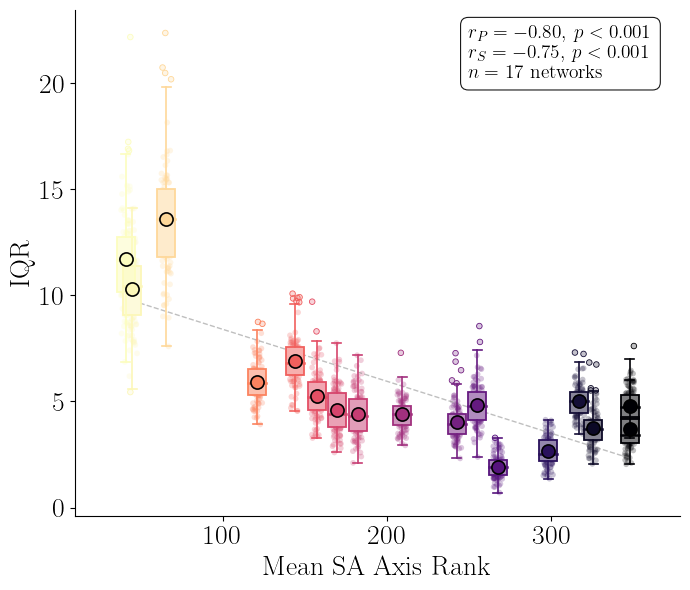

(np.float64(-0.7952146530287474),
 np.float64(0.00013580724746347408),
 np.float64(-0.752450980392157),
 np.float64(0.0004921108243565306))

In [4]:
# heterogeneity (IQR) vs. S-A axis rank, no size correction
plot_iqr_vs_sa_rank(
    iqr_results_17,
    ylabel=r"IQR",
    out_path=f"{OUT_DIR}/fig4c_iqr_vs_SArank_raw.pdf",
)

IQR ~ network size: slope=0.143720, intercept=2.3700, r=0.365, p=0.0000


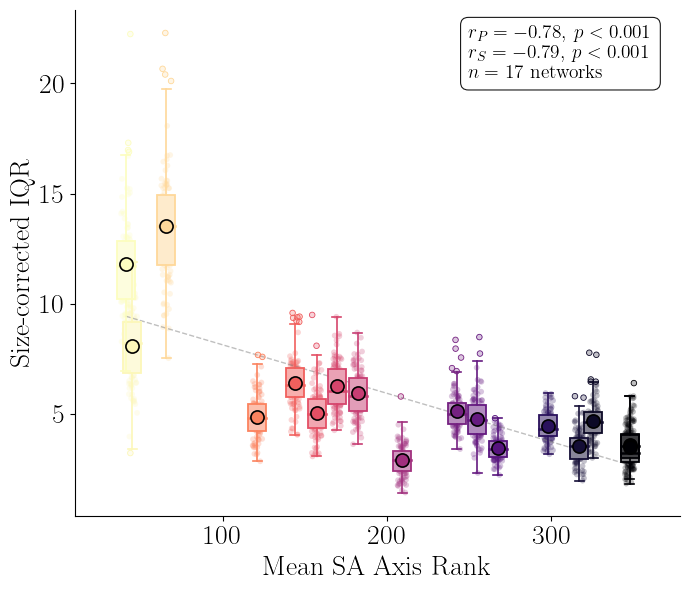

(np.float64(-0.7774960463171452),
 np.float64(0.000239373103756292),
 np.float64(-0.7941176470588236),
 np.float64(0.00014087555462921763))

In [5]:
# regress out network size, then re-plot panel (c)
all_ns, all_vals, all_labels = [], [], []
for net in net_order_17:
    n = net_sizes_17[net]
    for subj_idx, val in enumerate(iqr_results_17[net]):
        all_ns.append(n)
        all_vals.append(val)
        all_labels.append((net, subj_idx))

all_ns, all_vals = np.array(all_ns), np.array(all_vals)
slope, intercept, r, p, _ = linregress(all_ns, all_vals)
print(f"IQR ~ network size: slope={slope:.6f}, intercept={intercept:.4f}, r={r:.3f}, p={p:.4f}")

grand_mean = np.mean(all_vals)
residuals = all_vals - (slope * all_ns + intercept) + grand_mean

corrected_iqr_17 = {net: [] for net in net_order_17}
for (net, subj_idx), resid in zip(all_labels, residuals):
    corrected_iqr_17[net].append(resid)

plot_iqr_vs_sa_rank(
    corrected_iqr_17,
    ylabel=r"Size-corrected IQR",
    out_path=f"{OUT_DIR}/fig4c_iqr_vs_SArank_sizecorrected.pdf",
)